#### [ 연속영역분할 4: 워터셰드 (Watershed) ] <hr>

- 서로 붙어 있는 객체를 분리할 때 사용
- 진행 프로세스
    1. 이진화
    2. 거리 변환
    3. 확실한 전경 찾기
    4. 레이블링으로 마커 생성
    5. 워터셰드 실행

In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

<module 'cv_utils' from 'C:\\KDT14\\7_CV\\cv_utils.py'>

- **[1] 서로 붙은 두 원 만들기**

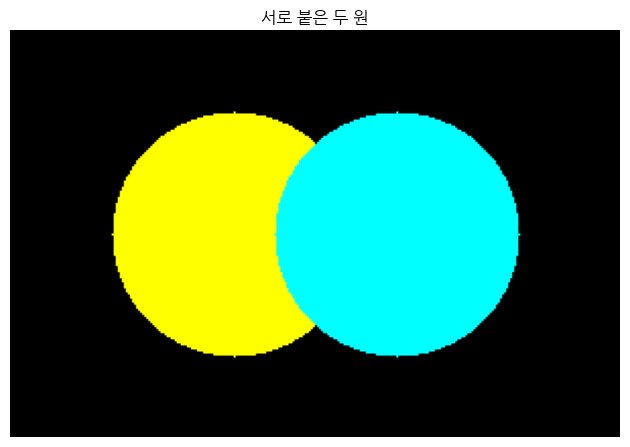

In [3]:
## ---------------------------------------------
## 실습 이미지 데이터 생성
## ---------------------------------------------
## 임의의 데이터 생성
imageNP = np.zeros((200, 300, 3), dtype=np.uint8)

cv2.circle(imageNP, (110, 100), 60, (0, 255, 255), -1)
cv2.circle(imageNP, (190, 100), 60, (255, 255, 0), -1)

## 시각화 출력
cv_utils.printPlots(1,1,["서로 붙은 두 원"], [cv2.cvtColor(imageNP, cv2.COLOR_BGR2RGB)])

- **[2] 이진화 진행**

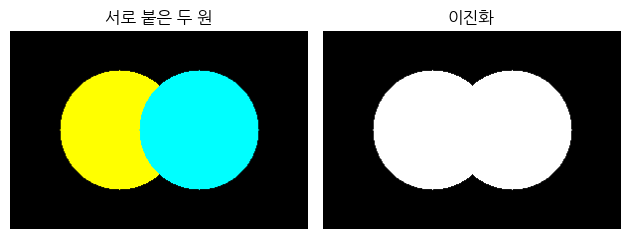

In [4]:
## 그레이스케일 변환
grayNP = cv2.cvtColor(imageNP, cv2.COLOR_BGR2GRAY)

## 오츠알고리즘 기반 임계값 찾아서 이진화
_, binaryNP = cv2.threshold( grayNP, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU )


## 시각화 출력
cv_utils.printPlots(1,2,["서로 붙은 두 원", "이진화"], 
               [cv2.cvtColor(imageNP, cv2.COLOR_BGR2RGB), binaryNP], 
               [None, 'gray'])


- **[3] 거리 변환으로 객체 중심 영역 찾기**
    - 확실한 배경, 확실한 전경, 불확실한 영역 설정
    - 과정
        * [확실한 배경] 이진 이미지  → 팽창 → 확실한 배경 영역 생성
        * [확실한 전경] 이진 이미지  → 거리 변환 → 임계값 처리 →  확실한 전경 영역 생성
        * [불확실한 영역]  확실한 배경 - 확실한 전경 → 불확실한 경계 영역 생성

    - 팽창 사용 경우
        * 배경과 객체가 이진화로 잘 구분되는 경우
        * 객체가 흰색, 배경이 검은색인 경우
        * 객체 주변의 넓은 후보 영역이 필요한 경우
        * 동전, 알약, 세포처럼 객체 모양이 비교적 단순한 경우
   

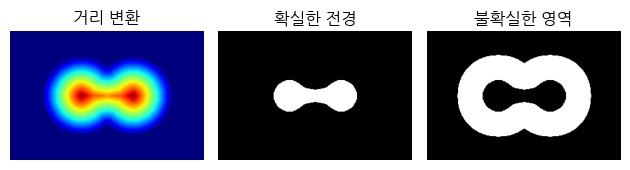

In [6]:
## [팽창용 커널]
##  => 3×3 크기의 커널(구조 요소)을 생성 
##  => 팽창 연산에서 주변 픽셀 확인할 때 사용
kernel = np.ones((3, 3), dtype=np.uint8)


## [확실한 배경 영역]
## => 이진 이미지(binaryNP)를 팽창
##    흰색 전경 영역을 바깥쪽으로 넓혀서 객체를 포함하는 '확실한 배경 영역'을 생성
##    iterations=3은 팽창 연산을 3번 반복 의미
sure_background = cv2.dilate( binaryNP,  kernel,  iterations=3)


## => 이진 이미지에서 거리 변환을 수행
##    각 흰색 전경 픽셀에 대해 가장 가까운 검은색 배경 픽셀까지의 거리를 계산
##    - cv2.DIST_L2 : 유클리드 거리 방식
##    - 5           : 거리 계산에 사용하는 마스크 크기
distance = cv2.distanceTransform( binaryNP,  cv2.DIST_L2,  5)


## [확실한 전경 영역 분리]
## => 거리 변환 결과에서 객체의 중심 부분만 추출
## - 최대 거리값의 60%보다 큰 부분만 흰색(255)으로 만듬
## - 객체의 경계 부분은 제외되고 중심 부분만 남게 됨
_, sure_foreground = cv2.threshold( distance,  0.6 * distance.max(),  255,  cv2.THRESH_BINARY)


## threshold 결과 float32 자료형 => 이진 영상 연산 위해 uint8 자료형 변환
## 변환 후 픽셀값:  배경 = 0, 확실한 전경 = 255
sure_foreground = sure_foreground.astype(np.uint8)


## [불확실한 영역 즉, Unknown 영역]
## - sure_background : 객체 중심과 객체 주변 영역이 포함
## - sure_foreground : 객체 중심 부분만 포함
##   => 객체인지 배경인지 아직 확실하지 않은 경계 영역 남음!
##
## 워터셰드에서 unknown 영역으로 사용
unknown = cv2.subtract(sure_background,sure_foreground )

## 시각화 출력
cv_utils.printPlots(1,3,["거리 변환", "확실한 전경", "불확실한 영역"], 
               [distance, sure_foreground, unknown], 
               ['jet', 'gray', 'gray'])


- **[4] 레이블링으로 워터셰드 마커 만들기**
    - 마커(Marker) 각 영역의 시작점을 표시

In [13]:
np.set_printoptions(threshold=np.inf)



전경 레이블 수: 1
마커에 포함된 값: [0 1 2]


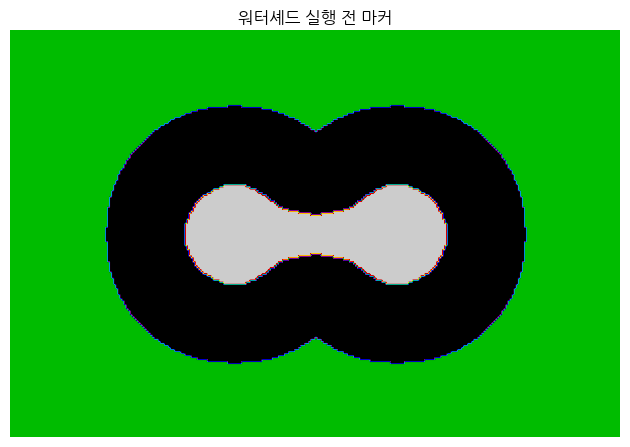

In [15]:
## 모여있는 같은 값 픽셀 라벨링 
num_labels, markers = cv2.connectedComponents( sure_foreground )
print("전경 레이블 수:", num_labels - 1)

## 배경을 1로 만들기 위해 모든 레이블에 1을 더함
markers = markers + 1

## 불확실한 영역은 0으로 지정
markers[unknown == 255] = 0
print("마커에 포함된 값:", np.unique(markers))

## 시각화 출력
cv_utils.printPlots(1,1,[ "워터셰드 실행 전 마커"], [markers],  ['nipy_spectral'])

- **[5] 워터셰드 실행**
- 마커를 기반으로 영역 분리
    * 0인 미정 영역을 주변 마커 쪽으로 확장
    * 같은 번호 마커 → 같은 객체 영역으로 합쳐짐
    * 다른 번호 마커 → 서로 다른 객체로 분리됨
    * 두 영역이 만나는 곳에 경계선 -1

In [9]:
## => 마커기반 영역 분리 진행
result_image = imageNP.copy()
markers_after = cv2.watershed( result_image, markers.copy() )

## =>  워터셰드 경계선 값은 -1
result_image[markers_after == -1] = [0, 0, 255]

print("워터셰드 실행 후 레이블 값:", np.unique(markers_after))

워터셰드 실행 후 레이블 값: [-1  1  2]


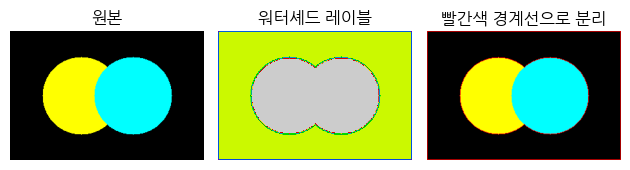

In [10]:
## 시각화 출력
rgbNP        = cv2.cvtColor(imageNP, cv2.COLOR_BGR2RGB)
result_rgbNP = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

cv_utils.printPlots(1,3,["원본", "워터셰드 레이블", "빨간색 경계선으로 분리"], 
               [rgbNP, markers_after, result_rgbNP], 
               [None, 'nipy_spectral', 'gray'])

## 핵심 정리

워터셰드 결과에서:
- `-1`: 객체 사이의 경계선
- `1`: 배경
- `2` 이상: 각각의 객체 영역

★★★워터셰드는 보통 **거리 변환**과 **레이블링**을 함께 사용하여 붙은 객체를 분리!!!